In [1]:
#INTERNSHIP PROJECT 1
#HousePricePrediction_[Aman]

In [2]:
# First we import all the libraries that we want to use in project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
#Task 1 — Data Loading & Exploration

In [4]:
#Load the CSV file 
df = pd.read_csv("Housing.csv")

In [5]:
#Display First 10 Row
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
#Check number of rows and Columns
print("Shape of Dataset:",df.shape)

Shape of Dataset: (545, 13)


In [7]:
#display column name
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [8]:
x = df.drop('price',axis=1)# Features
y = df['price']#Target

#Target Column = price
#Feature Column=  area, bedrooms,bathrooms ,stories,mainroad,etc
#Reason= the price column represent the house price we wanr to predict , while the remaning columns contain information about the house that helps predict  its price


In [9]:
#Check for missing values
df.isnull().sum()
#all values are 0 means there is no missing value

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
#check data set infomation
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [11]:
#Generate statistical summary
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [12]:
#Task 1  Completed

In [13]:
#Task 2 — Data Cleaning 

In [14]:
#handle missing value
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [15]:
# no missing values are present in dataset


In [16]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [17]:
#Check Categorical Columns
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
#convert categorical columns inro numeric form
df = pd.get_dummies(df,drop_first=True)

In [19]:
#verify
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [20]:
#Task 2 completed

In [21]:
#Task 3 — Model Building 

In [22]:
#Split the data into training and test sets (80/20) 

X = df.drop('price',axis=1)
y = df['price']


In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state = 42
)
print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)


Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


In [24]:
#Train a Linear Regression model to predict house price 
from sklearn.linear_model import LinearRegression
#create and train linear model
lr = LinearRegression()
lr.fit(X_train,y_train)

#make predictions
y_pred_lr = lr.predict(X_test)
#view
print("Predicted Prices:")
print(y_pred_lr[:5])

Predicted Prices:
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955]


In [25]:
#Evaluate Model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae_lr = mean_absolute_error(y_test,y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("MAE:", mae_lr)
print("RMSE",rmse_lr)
print("R2 Score", r2_lr)

MAE: 970043.4039201637
RMSE 1324506.9600914388
R2 Score 0.6529242642153184


In [26]:
# This  shows that model has predictive performance and capture a significant portion of the relationship between house features and price


In [27]:
#Train 2nd model
#import and Train Random Forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train,y_train)
#make predictions
y_pred_rf = rf.predict(X_test)
print("Predicted Prices:")
print(y_pred_rf[:5])

Predicted Prices:
[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [28]:
mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2rf = r2_score(y_test, y_pred_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2rf)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [29]:
#comparision
comparison = pd.DataFrame({
    'Model':['linear Regression','Random Forest'],
    'MAE':[mae_lr, mae_rf],
    'RMSE':[rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2rf]
})
print(comparison)

               Model           MAE          RMSE  R2 Score
0  linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


In [30]:
# Therefore, Linear Regression model perform better on this dataset

In [31]:
#Task 4 — Visualization

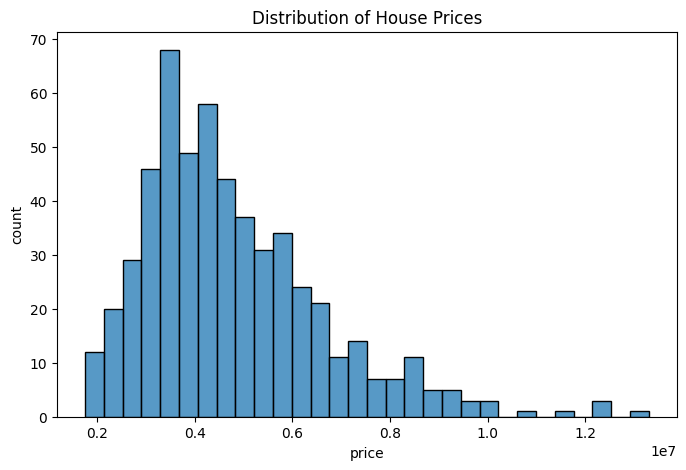

In [32]:
#Chart 1: Histogram showing the distribution of house prices
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("price")
plt.ylabel("count")
plt.savefig("Histogram.png")
plt.show()

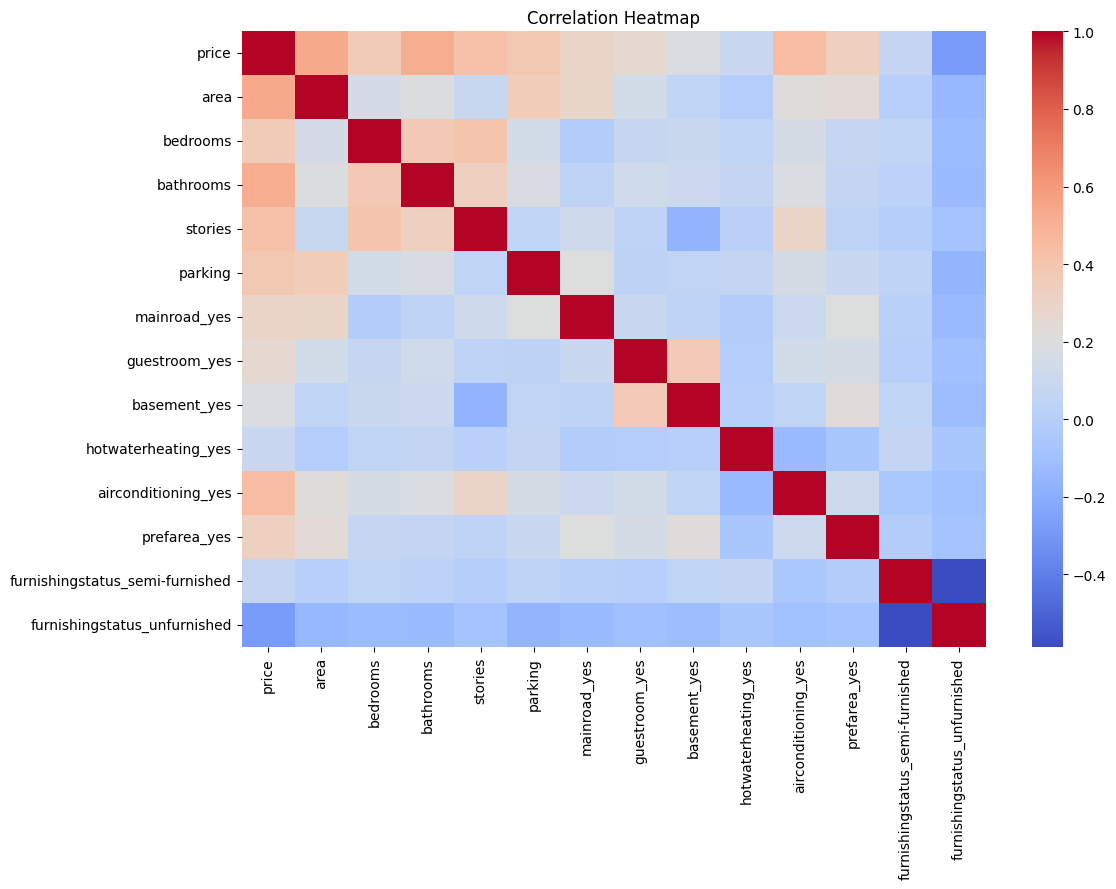

In [33]:
#Chart 2 Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("Heatmap.png")
plt.show()

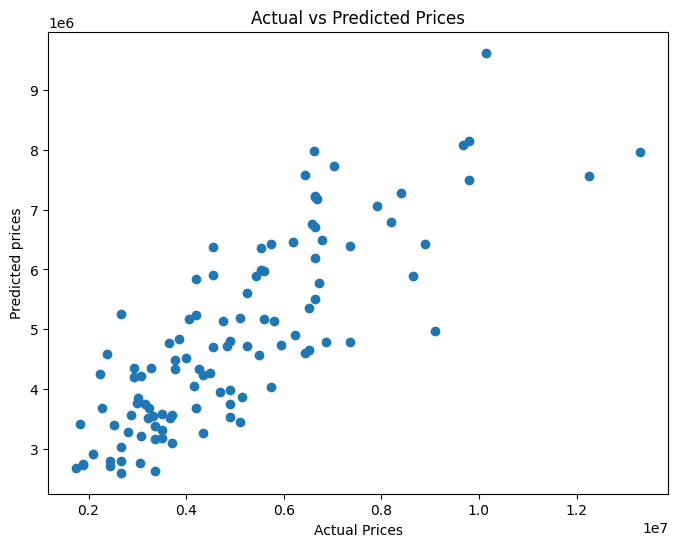

In [34]:
#Chart 3  Actual vs Predicted Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted prices")
plt.title("Actual vs Predicted Prices")
plt.savefig("Actual_vs_Predicted.png")
plt.show()